# Muziekclassificatie — Ongesuperviseerd (GMM)

**Project R.E.M. · ML-notebook**

Laat de data zelf bepalen hoeveel muziekgroepen er zijn via Gaussian Mixture Models.
Vergelijkt twee scenario's:
- **k=3 geforceerd** — drie groepen, direct vergelijkbaar met calm/neutral/energy
- **k=optimaal** — aantal clusters gekozen door BIC (laagste score = beste model)

Alle deelnemers worden samengenomen in één globaal model.

**Artefacten:** `models/music_unsupervised/gmm_k3.pkl` · `gmm_opt.pkl` · `scaler.pkl` · `config.json`  
**Uitvoer:** `data/analysis/music_unsupervised/`

In [1]:
from __future__ import annotations

import json
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
print("Imports OK")

Imports OK


In [2]:
# ── Configuratie ──────────────────────────────────────────────────────────────
# REUSE_MODEL = True  → laad bestaande modellen vanuit models/music_unsupervised/
# REUSE_MODEL = False → fit nieuwe modellen en sla op
REUSE_MODEL = False

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Paden ─────────────────────────────────────────────────────────────────────
PROJECT_ROOT  = Path().resolve().parent.parent
PLAYLISTS_DIR = PROJECT_ROOT / "data" / "playlists"
OUTPUT_DIR    = PROJECT_ROOT / "data" / "analysis" / "music_unsupervised"
MODELS_DIR    = PROJECT_ROOT / "models" / "music_unsupervised"

# ── Audio-kenmerken ───────────────────────────────────────────────────────────
FEATURES = ["tempo", "energy", "valence", "danceability", "acousticness", "loudness"]

# ── Voorfilter ────────────────────────────────────────────────────────────────
SPEECHINESS_MAX = 0.66
LIVENESS_MAX    = 0.80

# ── GMM zoekbereik ────────────────────────────────────────────────────────────
K_MIN, K_MAX = 2, 10

# ── Visuele stijl (donker thema) ──────────────────────────────────────────────
DARK = {
    "figure.facecolor": "#0f1218",
    "axes.facecolor":   "#181e2a",
    "axes.edgecolor":   "#4a5568",
    "axes.labelcolor":  "#e2e8f0",
    "xtick.color":      "#e2e8f0",
    "ytick.color":      "#e2e8f0",
    "text.color":       "#e2e8f0",
    "grid.color":       "#2d3748",
    "grid.alpha":       0.5,
    "font.family":      "monospace",
    "legend.facecolor": "#1a2035",
    "legend.edgecolor": "#4a5568",
}
plt.rcParams.update(DARK)
plt.rcParams["figure.dpi"] = 120

# Okabe-Ito basis + uitbreidingen voor meerdere clusters
OKABE_ITO = ["#56b4e9", "#e69f00", "#009e73", "#f0e442",
             "#0072b2", "#d55e00", "#cc79a7", "#999999", "#e2e8f0", "#7fcdbb"]

print(f"PROJECT_ROOT : {PROJECT_ROOT}")
print(f"REUSE_MODEL  : {REUSE_MODEL}")

PROJECT_ROOT : C:\Users\astri\Desktop\Data_Scientist\Eindwerk\spotify-project
REUSE_MODEL  : False


---
## 1. Data laden

Alle deelnemers worden samengenomen — het model zoekt naar patronen in de volledige muziekbibliotheek.

In [3]:
def load_all_songs() -> pd.DataFrame:
    """Laad combined.csv van alle deelnemers en combineer."""
    frames = []
    for participant_dir in sorted(PLAYLISTS_DIR.iterdir()):
        if not participant_dir.is_dir():
            continue
        codename = participant_dir.name
        csv_path = participant_dir / "playlists_generated" / "combined.csv"
        if not csv_path.exists():
            continue
        df = pd.read_csv(csv_path)
        df["participant"] = codename
        frames.append(df)

    if not frames:
        raise FileNotFoundError(
            f"Geen combined.csv gevonden onder {PLAYLISTS_DIR}.\n"
            "Verwerk eerst de playlists met de spotify_cli.py pipeline."
        )

    df_all = pd.concat(frames, ignore_index=True)

    # Dedupliceren op URI (nummers die meerdere deelnemers delen)
    if "uri" in df_all.columns:
        n_before = len(df_all)
        df_all = df_all.drop_duplicates(subset="uri", keep="first")
        print(f"  URI-deduplicatie: {n_before - len(df_all)} duplicaten verwijderd")

    return df_all


def prefilter(df: pd.DataFrame) -> pd.DataFrame:
    """Verwijder live-opnames en gesproken-woord tracks."""
    n_before = len(df)
    mask = pd.Series(True, index=df.index)
    if "speechiness" in df.columns:
        mask &= df["speechiness"] <= SPEECHINESS_MAX
    if "liveness" in df.columns:
        mask &= df["liveness"] <= LIVENESS_MAX
    df = df[mask].copy()
    n_removed = n_before - len(df)
    if n_removed:
        print(f"  Voorfilter: {n_removed} tracks verwijderd (speech/live)")
    return df


df_raw = load_all_songs()
print(f"  Geladen: {len(df_raw)} nummers, {df_raw['participant'].nunique()} deelnemer(s)")

df = prefilter(df_raw)

# Rijen met ontbrekende kenmerken verwijderen
missing_feats = [f for f in FEATURES if f not in df.columns]
if missing_feats:
    raise ValueError(f"Ontbrekende kolommen: {missing_feats}")
n_before = len(df)
df = df.dropna(subset=FEATURES).copy()
print(f"  Na NaN-verwijdering: {len(df)} nummers ({n_before - len(df)} verwijderd)")

  URI-deduplicatie: 213 duplicaten verwijderd
  Geladen: 6198 nummers, 2 deelnemer(s)
  Na NaN-verwijdering: 6198 nummers (0 verwijderd)


---
## 2. Normalisatie

**Waarom StandardScaler?**  
GMM gaat uit van Gaussische verdelingen. StandardScaler brengt alle kenmerken naar gemiddelde 0 en standaarddeviatie 1, zodat geen enkel kenmerk het model domineert door een groter numeriek bereik (bijv. tempo in BPM vs energy in 0–1).

In [4]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

scaler_path = MODELS_DIR / "scaler.pkl"

if REUSE_MODEL:
    if not scaler_path.exists():
        raise FileNotFoundError(
            f"REUSE_MODEL=True maar scaler niet gevonden: {scaler_path}\n"
            "Zet REUSE_MODEL=False en voer het notebook opnieuw uit."
        )
    scaler = joblib.load(scaler_path)
    print(f"Scaler geladen vanuit {scaler_path.name}")
else:
    scaler = StandardScaler()
    scaler.fit(df[FEATURES].values)
    joblib.dump(scaler, scaler_path)
    print(f"Scaler gefittet en opgeslagen → {scaler_path.name}")

X = scaler.transform(df[FEATURES].values)
print(f"Feature-matrix: {X.shape}")

Scaler gefittet en opgeslagen → scaler.pkl
Feature-matrix: (6198, 6)


---
## 3. GMM-modelselectie — BIC (k=2..10)

BIC (Bayesian Information Criterion) beloont modellen die de data goed verklaren maar straft onnodig complexe modellen (te veel clusters). De laagste BIC-score wijst het optimale aantal clusters aan.

In [5]:
gmm_k3_path  = MODELS_DIR / "gmm_k3.pkl"
gmm_opt_path = MODELS_DIR / "gmm_opt.pkl"
config_path  = MODELS_DIR / "config.json"

if REUSE_MODEL:
    for p in [gmm_k3_path, gmm_opt_path, config_path]:
        if not p.exists():
            raise FileNotFoundError(
                f"REUSE_MODEL=True maar bestand niet gevonden: {p}\n"
                "Zet REUSE_MODEL=False en voer het notebook opnieuw uit."
            )
    gmm_k3  = joblib.load(gmm_k3_path)
    gmm_opt = joblib.load(gmm_opt_path)
    with open(config_path, encoding="utf-8") as f:
        config = json.load(f)
    optimal_k = config["optimal_k"]
    # Herstel BIC-resultaten voor visualisatie
    bic_results = config.get("bic_sweep", {})
    print(f"Modellen geladen. Optimaal k={optimal_k}")

else:
    # Fit GMMs voor k=2..10
    print(f"GMMs fitten voor k={K_MIN}..{K_MAX}...")
    bic_results: dict[int, dict] = {}
    for k in range(K_MIN, K_MAX + 1):
        gmm = GaussianMixture(
            n_components=k,
            covariance_type="full",
            n_init=5,
            random_state=RANDOM_STATE,
        )
        gmm.fit(X)
        labels = gmm.predict(X)
        sil = silhouette_score(X, labels) if k > 1 else 0.0
        bic_results[k] = {
            "bic":        gmm.bic(X),
            "aic":        gmm.aic(X),
            "silhouette": sil,
            "model":      gmm,
        }
        print(f"  k={k:2d}: BIC={gmm.bic(X):>10.0f}, silhouette={sil:.3f}")

    optimal_k = min(bic_results, key=lambda k: bic_results[k]["bic"])
    print(f"\n→ Optimaal k = {optimal_k} (laagste BIC)")

    gmm_k3  = bic_results[3]["model"]
    gmm_opt = bic_results[optimal_k]["model"]

    # Sla modellen op
    joblib.dump(gmm_k3,  gmm_k3_path)
    joblib.dump(gmm_opt, gmm_opt_path)
    print(f"Modellen opgeslagen → {gmm_k3_path.name}, {gmm_opt_path.name}")

    # Sla config op
    config = {
        "optimal_k":        optimal_k,
        "features":         FEATURES,
        "n_songs":          len(df),
        "n_participants":   df["participant"].nunique(),
        "k3_bic":           bic_results[3]["bic"],
        "k3_silhouette":    bic_results[3]["silhouette"],
        "opt_bic":          bic_results[optimal_k]["bic"],
        "opt_silhouette":   bic_results[optimal_k]["silhouette"],
        "bic_sweep": {
            str(k): {"bic": v["bic"], "aic": v["aic"], "silhouette": v["silhouette"]}
            for k, v in bic_results.items()
        },
    }
    with open(config_path, "w", encoding="utf-8") as f:
        json.dump(config, f, indent=2)
    print(f"Config opgeslagen → {config_path.name}")

GMMs fitten voor k=2..10...
  k= 2: BIC=     74587, silhouette=0.394
  k= 3: BIC=     68439, silhouette=0.138
  k= 4: BIC=     66633, silhouette=0.091
  k= 5: BIC=     65210, silhouette=0.074
  k= 6: BIC=     63694, silhouette=0.030
  k= 7: BIC=     63202, silhouette=0.032
  k= 8: BIC=     62947, silhouette=0.042
  k= 9: BIC=     62897, silhouette=0.028
  k=10: BIC=     62478, silhouette=0.018

→ Optimaal k = 10 (laagste BIC)
Modellen opgeslagen → gmm_k3.pkl, gmm_opt.pkl
Config opgeslagen → config.json


---
## 4. Diagnostiek — BIC/silhouette curve

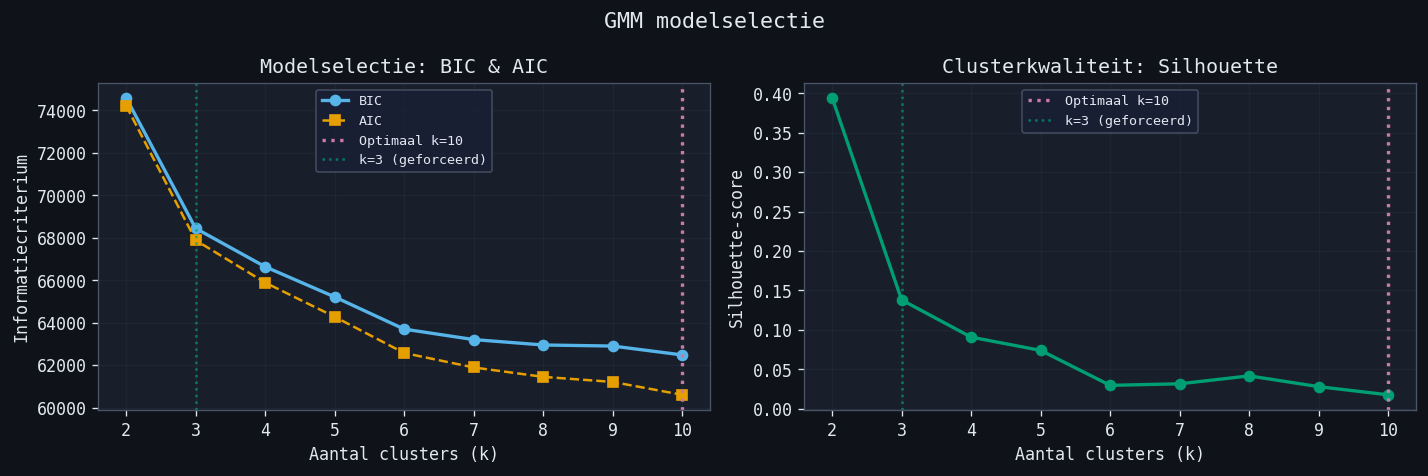


Optimaal k=10  |  BIC=62478  |  silhouette=0.018
k=3 geforceerd        |  BIC=68439  |  silhouette=0.138


In [6]:
# Haal BIC-data op uit bic_results (bij REUSE_MODEL=False) of config (bij REUSE_MODEL=True)
if REUSE_MODEL:
    sweep = config.get("bic_sweep", {})
    ks   = sorted(int(k) for k in sweep)
    bics = [sweep[str(k)]["bic"]        for k in ks]
    aics = [sweep[str(k)]["aic"]        for k in ks]
    sils = [sweep[str(k)]["silhouette"] for k in ks]
else:
    ks   = sorted(bic_results)
    bics = [bic_results[k]["bic"]        for k in ks]
    aics = [bic_results[k]["aic"]        for k in ks]
    sils = [bic_results[k]["silhouette"] for k in ks]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# BIC & AIC
ax1.plot(ks, bics, "o-", color="#56b4e9", label="BIC", linewidth=2)
ax1.plot(ks, aics, "s--", color="#e69f00", label="AIC", linewidth=1.5)
ax1.axvline(optimal_k, color="#cc79a7", linestyle=":", linewidth=2,
            label=f"Optimaal k={optimal_k}")
if optimal_k != 3:
    ax1.axvline(3, color="#009e73", linestyle=":", linewidth=1.5, alpha=0.7,
                label="k=3 (geforceerd)")
ax1.set_xlabel("Aantal clusters (k)")
ax1.set_ylabel("Informatiecriterium")
ax1.set_title("Modelselectie: BIC & AIC")
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# Silhouette
ax2.plot(ks, sils, "o-", color="#009e73", linewidth=2)
ax2.axvline(optimal_k, color="#cc79a7", linestyle=":", linewidth=2,
            label=f"Optimaal k={optimal_k}")
if optimal_k != 3:
    ax2.axvline(3, color="#009e73", linestyle=":", linewidth=1.5, alpha=0.7,
                label="k=3 (geforceerd)")
ax2.set_xlabel("Aantal clusters (k)")
ax2.set_ylabel("Silhouette-score")
ax2.set_title("Clusterkwaliteit: Silhouette")
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

fig.suptitle("GMM modelselectie", fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nOptimaal k={optimal_k}  |  BIC={config['opt_bic']:.0f}  |  silhouette={config['opt_silhouette']:.3f}")
print(f"k=3 geforceerd        |  BIC={config['k3_bic']:.0f}  |  silhouette={config['k3_silhouette']:.3f}")

---
## 5. Classificatie & clusterprofielen

In [7]:
# Labels & kansen toewijzen voor beide modellen
df = df.copy()

for label, gmm, k in [("k3", gmm_k3, 3), ("opt", gmm_opt, optimal_k)]:
    probs = gmm.predict_proba(X)
    df[f"cluster_{label}"]    = gmm.predict(X)
    df[f"confidence_{label}"] = probs.max(axis=1)

# Clusterprofielen (gemiddelde kenmerken per cluster)
def cluster_profiles(df: pd.DataFrame, cluster_col: str) -> pd.DataFrame:
    return (
        df.groupby(cluster_col)[FEATURES]
        .agg(["mean", "std"])
        .round(3)
    )

profiles_k3  = cluster_profiles(df, "cluster_k3")
profiles_opt = cluster_profiles(df, "cluster_opt")

print("Clusterprofiel k=3:")
display(profiles_k3)

print(f"\nClusterprofiel k={optimal_k} (optimaal):")
display(profiles_opt)

# Verdeling per deelnemer
print("\nClusterverdeling per deelnemer (k=3):")
display(
    df.groupby(["participant", "cluster_k3"])
    .size()
    .unstack(fill_value=0)
    .rename(columns=lambda c: f"cluster {c}")
)

Clusterprofiel k=3:


tempo         energy        valence        danceability         \
               mean     std   mean    std    mean    std         mean    std   
cluster_k3                                                                     
0           126.181  24.662  0.794  0.130   0.544  0.232        0.608  0.149   
1           101.668  32.950  0.044  0.039   0.196  0.121        0.371  0.138   
2           116.981  27.583  0.510  0.215   0.465  0.266        0.573  0.163   

           acousticness        loudness         
                   mean    std     mean    std  
cluster_k3                                      
0                 0.022  0.024   -5.739  1.930  
1                 0.986  0.014  -27.538  5.906  
2                 0.476  0.292   -9.755  4.200


Clusterprofiel k=10 (optimaal):


tempo         energy        valence        danceability         \
                mean     std   mean    std    mean    std         mean    std   
cluster_opt                                                                     
0             72.917   7.124  0.020  0.017   0.173  0.111        0.316  0.103   
1            128.426   9.616  0.528  0.181   0.234  0.117        0.607  0.106   
2            112.842  16.124  0.676  0.153   0.655  0.206        0.692  0.112   
3            114.722  32.333  0.036  0.026   0.228  0.121        0.416  0.122   
4            130.903  25.658  0.863  0.085   0.526  0.223        0.541  0.145   
5            112.441  31.769  0.170  0.086   0.220  0.140        0.407  0.170   
6             96.033  16.630  0.544  0.173   0.506  0.226        0.607  0.142   
7            141.009  31.106  0.539  0.193   0.588  0.238        0.546  0.133   
8            111.255  28.742  0.313  0.121   0.107  0.053        0.334  0.143   
9            125.055  23.782  0.769  0.130   0.546  0.234        0.630  0.143   

            acousticness        loudness         
                    mean    std     mean    std  
cluster_opt                                      
0                  0.987  0.009  -30.548  5.744  
1                  0.451  0.257   -8.788  2.580  
2                  0.125  0.069   -7.978  3.207  
3                  0.993  0.003  -28.106  4.787  
4                  0.002  0.002   -5.324  1.886  
5                  0.920  0.051  -16.931  6.544  
6                  0.510  0.222   -7.871  2.240  
7                  0.501  0.243  -10.217  3.757  
8                  0.544  0.273  -13.860  5.026  
9                  0.026  0.017   -5.666  1.700


Clusterverdeling per deelnemer (k=3):


cluster_k3,cluster 0,cluster 1,cluster 2
participant,,,
courgette,1818,750,3152
peer,154,19,305


---
## 6. PCA-scatter — k=3 vs optimaal

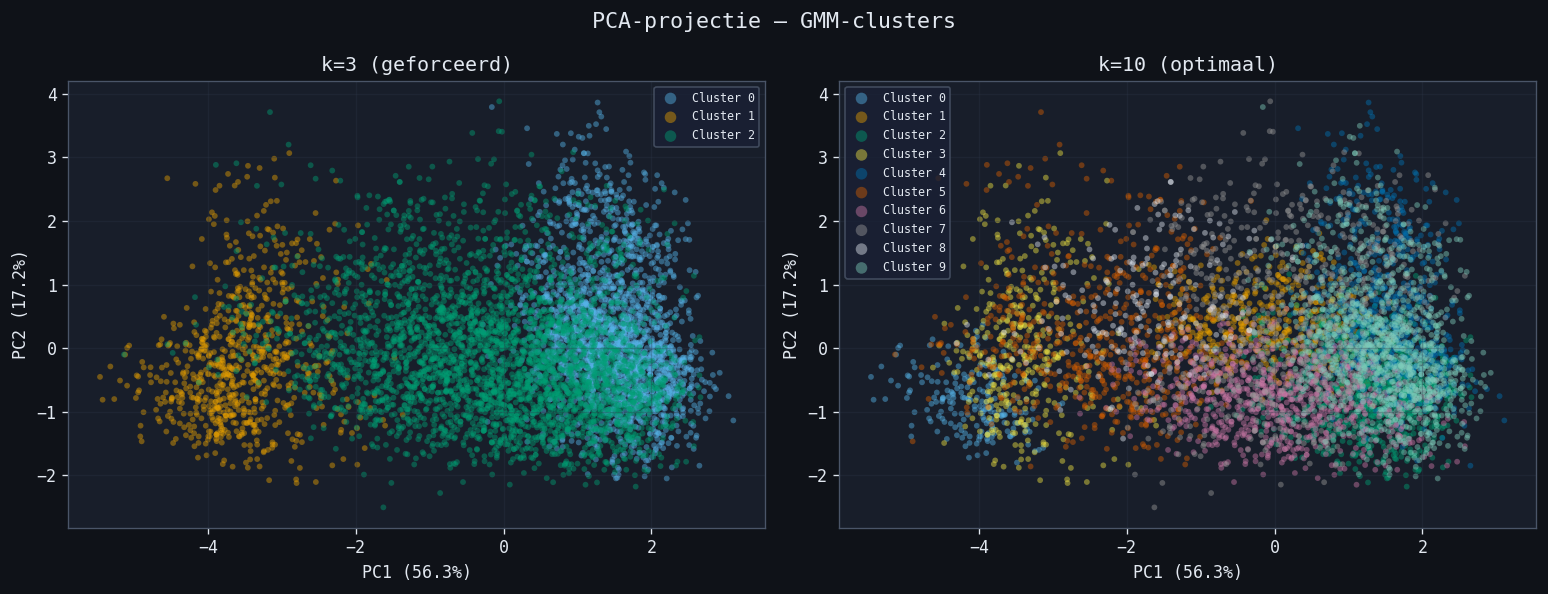

In [8]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca.fit_transform(X)
var_explained = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (label, k) in zip(axes, [("k3", 3), ("opt", optimal_k)]):
    cluster_col = f"cluster_{label}"
    for i in range(k):
        mask = df[cluster_col] == i
        color = OKABE_ITO[i % len(OKABE_ITO)]
        ax.scatter(
            X_2d[mask, 0], X_2d[mask, 1],
            c=color, label=f"Cluster {i}",
            alpha=0.45, s=12, edgecolors="none",
        )
    title = f"k=3 (geforceerd)" if label == "k3" else f"k={optimal_k} (optimaal)"
    ax.set_title(title)
    ax.set_xlabel(f"PC1 ({var_explained[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({var_explained[1]*100:.1f}%)")
    ax.legend(fontsize=7, markerscale=2)
    ax.grid(True, alpha=0.3)

fig.suptitle("PCA-projectie — GMM-clusters", fontsize=13)
plt.tight_layout()
plt.show()

---
## 7. Opslaan

In [9]:
# Geclassificeerde CSVs
internal_cols = [c for c in df.columns if c.startswith("prob_")]
save_cols = [c for c in df.columns if c not in internal_cols]

csv_k3  = OUTPUT_DIR / "classified_songs_k3.csv"
csv_opt = OUTPUT_DIR / f"classified_songs_k{optimal_k}.csv"

df[save_cols].to_csv(csv_k3,  index=False)
df[save_cols].to_csv(csv_opt, index=False)
print(f"  ✓ {csv_k3.name}")
print(f"  ✓ {csv_opt.name}")

# Clusterprofielen
profiles_k3.to_csv(OUTPUT_DIR / "cluster_means_k3.csv")
profiles_opt.to_csv(OUTPUT_DIR / f"cluster_means_k{optimal_k}.csv")
print(f"  ✓ cluster_means_k3.csv")
print(f"  ✓ cluster_means_k{optimal_k}.csv")

print("\nKlaar.")

  ✓ classified_songs_k3.csv
  ✓ classified_songs_k10.csv
  ✓ cluster_means_k3.csv
  ✓ cluster_means_k10.csv

Klaar.
